# NHANES Dataset Analysis: Waist Circumference Prediction using kNN

## Overview

This notebook presents an analysis of the **National Health and Nutrition Examination Survey (NHANES)** dataset, focusing on predicting waist circumference using k-Nearest Neighbors (kNN) models. The analysis compares **diabetic vs. non-diabetic participants** to identify disease-specific patterns.

### Dataset Information

- **Source**: [NHANES CDC Database](https://wwwn.cdc.gov/nchs/nhanes/)
- **Focus**: Comparison between diabetic and non-diabetic participants
- **Objective**: Identify relevant features for conditional mean and variance in waist circumference prediction
- **Preprocessing**: Unnecessary variables and missing data have been removed (see data directory)

---

## Methodology

### 1. Data Preprocessing

**Stratification**:
- Dataset split by diabetes status (0 = non-diabetic, 1 = diabetic)
- Each group analyzed separately to identify disease-specific predictors
- Train-test split (50/50) for cross-validation

**Independent variables (X)**:
- **RIDAGEYR**: Age (years)
- **BMXHT**: Height (cm)
- **BMXWT**: Weight (kg)
- **BMXBMI**: Body Mass Index
- **BPXDI1**: Diastolic blood pressure
- **BPXSY1**: Systolic blood pressure
- **BPXPLS**: Pulse rate
- **LBDSCHSI**: Total cholesterol (SI units)
- **LBXSTR**: Triglycerides
- **LBXSGL**: Glucose (serum)
- **LBXGH**: Glycohemoglobin (%)

**Dependent variable (Y)**:
- **BMXWAIST**: Waist circumference (cm)

### 2. kNN Model Configuration

Dual modeling approach for each group (diabetic/non-diabetic):

1. **Conditional mean model**: Predicts expected waist circumference
2. **Conditional variance model**: Predicts variability in waist circumference

**Hyperparameters**:
- Search grid for k: [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
- Separate grids for mean (`grida`) and variance (`gridv`)
- Automatic feature selection with statistical significance testing

### 3. ROC Analysis

**Conditional ROC Curves**:
- Compare predictions from non-diabetic vs. diabetic models
- Compute Area Under the Curve (AUC) for each participant
- Analyze how well the models discriminate between the two groups

**Residual Analysis**:
- Calculate prediction residuals for both models
- Use residuals to assess model performance differences

### 4. Visualization

3D scatter plot showing:
- **Weight vs. BMI vs. AUC**
- Demonstrates discrimination ability across anthropometric variables
- Color gradient (viridis) indicates AUC values

---

## Expected Results

1. **Disease-specific features**: Identify which variables are most relevant for diabetic vs. non-diabetic participants
2. **Mean predictors**: Determine primary drivers of waist circumference in each group
3. **Variance predictors**: Understand what factors increase waist circumference variability
4. **Discrimination**: Quantify how well models can distinguish between diabetic and non-diabetic patterns

---

## Technical Notes

- **Reproducibility**: Fixed seeds for numpy and random
- **Data type**: float32 for computational efficiency
- **Sample size**: 50/50 train-test split for validation
- **ROC calculation**: Computed for first 1000 participants in test set

In [1]:
# Import required libraries

import sys
sys.path.append("../..")  # Add path to import knnvs module

# Standard libraries
import math
import random
import logging

# Data analysis libraries
import numpy as np
import pandas as pd

# Machine learning libraries
import sklearn.metrics as skl
from sklearn.model_selection import train_test_split

# knnvs module (custom kNN implementation)
from knnvs import KnnBag, KnnVar, initialize_knn, roc

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure visualization parameters
mpl.rcParams['axes.labelsize'] = 9  # Axis label size

## Data Loading and Preparation

In this section we load the NHANES dataset and **stratify by diabetes status**.

**Selected variables**:
- **Independent (X)**: age, height, weight, BMI, blood pressure (systolic/diastolic), pulse rate, cholesterol, triglycerides, glucose, glycohemoglobin
- **Dependent (Y)**: waist circumference (BMXWAIST, in cm)

**Important**: The same variable set is used for both diabetic and non-diabetic groups to enable direct comparison of feature importance.

In [2]:
# Set seeds for reproducibility
random.seed(1)
np.random.seed(1)

# Grids for hyperparameter k search
# grida: k values for conditional mean model
# gridv: k values for conditional variance model
grida = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])
gridv = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])

# Load dataset
df = pd.read_csv('data/nhanes20220129.csv')

# Stratify by diabetes status
df0 = df.loc[df['diabetes'] == 0]  # Non-diabetic participants
df1 = df.loc[df['diabetes'] == 1]  # Diabetic participants

# Define dependent and independent variables
out = 'BMXWAIST'  # Target variable: waist circumference (cm)
inp = np.array([
    "RIDAGEYR",   # Age (years)
    "BMXHT",      # Height (cm)
    "BMXWT",      # Weight (kg)
    "BMXBMI",     # Body Mass Index
    "BPXDI1",     # Diastolic blood pressure
    "BPXSY1",     # Systolic blood pressure
    "BPXPLS",     # Pulse rate
    "LBDSCHSI",   # Total cholesterol (SI units)
    "LBXSTR",     # Triglycerides
    "LBXSGL",     # Glucose (serum)
    "LBXGH"       # Glycohemoglobin (%)
])

# Extract arrays for non-diabetic participants
y0 = df0[out].to_numpy().astype('float32')
x0 = df0[inp].to_numpy().astype('float32')

# Extract arrays for diabetic participants
y1 = df1[out].to_numpy().astype('float32')
x1 = df1[inp].to_numpy().astype('float32')

# Split each group into train/test (50/50 split)
# Non-diabetic: x01/y01 for training, x02/y02 for testing
x01, x02, y01, y02 = train_test_split(x0, y0, test_size=0.50, random_state=11)

# Diabetic: x11/y11 for training, x12/y12 for testing
x11, x12, y11, y12 = train_test_split(x1, y1, test_size=0.50, random_state=11)

print(f'Non-diabetic participants: {len(y0)} total ({len(y01)} train, {len(y02)} test)')
print(f'Diabetic participants: {len(y1)} total ({len(y11)} train, {len(y12)} test)')

Non-diabetic participants: 49946 total (24973 train, 24973 test)
Diabetic participants: 9026 total (4513 train, 4513 test)


## kNN Model Initialization and Training - Non-Diabetic Participants

The `initialize_knn` function performs feature selection and model training for **non-diabetic participants**.

**Process**:
1. **Feature selection**: Identifies the most relevant variables for non-diabetics through statistical tests
2. **Cross-validation**: Finds the optimal k value for each model
3. **Training**: Fits both conditional mean and variance models

**Parameters**:
- `x01`, `y01`: Training data (non-diabetic participants only)
- `grida`, `gridv`: Search grids for k (mean and variance)
- `quantile`: Threshold for feature selection (1 - α = 0.99)

**Returns**:
- `knna0`: kNN model for conditional mean
- `fa0`: Indices of selected features for mean
- `ka0`: Optimal k value for mean
- `pva0`: P-values of features (mean)
- `knnv0`: kNN model for conditional variance
- `fv0`: Indices of selected features for variance
- `kv0`: Optimal k value for variance
- `pvv0`: P-values of features (variance)

In [3]:
# Initialize and train kNN models for NON-DIABETIC participants
knna0, fa0, ka0, pva0, knnv0, fv0, kv0, pvv0 = initialize_knn(
    x01, y01, 
    grida, gridv, 
    quantile=(1 - 0.01)  # 99% confidence level
)

# Create combined model including both mean and variance
knn0 = KnnVar(knna0, knnv0)

# Display selected features for non-diabetic participants
print('Non-diabetic participants - selected features for mean:\n  {}'.format(inp[fa0]))
print('Non-diabetic participants - selected features for variance:\n  {}'.format(inp[fv0]))
print(f'\nOptimal k value for mean: {ka0}')
print(f'Optimal k value for variance: {kv0}')

Non-diabetic participants - selected features for mean:
  ['BMXWT' 'BMXBMI']
Non-diabetic participants - selected features for variance:
  ['RIDAGEYR']

Optimal k value for mean: 100
Optimal k value for variance: 100


## kNN Model Initialization and Training - Diabetic Participants

Now we train a separate model for **diabetic participants** to identify disease-specific patterns.

**Expected differences**:
- Different features may be selected compared to non-diabetic model
- Optimal k values may differ
- Variance predictors may be particularly different due to metabolic dysregulation

**Note**: If no features pass the significance test, the model will use all features (indicated by a warning message).

In [4]:
# Initialize and train kNN models for DIABETIC participants
knna1, fa1, ka1, pva1, knnv1, fv1, kv1, pvv1 = initialize_knn(
    x11, y11, 
    grida, gridv, 
    quantile=(1 - 0.01)  # 99% confidence level
)

# Create combined model including both mean and variance
knn1 = KnnVar(knna1, knnv1)

# Display selected features for diabetic participants
print('Diabetic participants - selected features for mean:\n  {}'.format(inp[fa1]))
print('Diabetic participants - selected features for variance:\n  {}'.format(inp[fv1]))
print(f'\nOptimal k value for mean: {ka1}')
print(f'Optimal k value for variance: {kv1}')

No features passed significance test at quantile=0.99. Using all 11 features.


Diabetic participants - selected features for mean:
  ['BMXWT' 'BMXBMI']
Diabetic participants - selected features for variance:
  ['RIDAGEYR' 'BMXHT' 'BMXWT' 'BMXBMI' 'BPXDI1' 'BPXSY1' 'BPXPLS' 'LBDSCHSI'
 'LBXSTR' 'LBXSGL' 'LBXGH']

Optimal k value for mean: 20
Optimal k value for variance: 100


## ROC Analysis: Model Discrimination

In this section we assess how well the two models (non-diabetic vs. diabetic) can discriminate between the groups.

**Methodology**:
1. **Combine test sets**: Concatenate non-diabetic and diabetic test data
2. **Dual predictions**: Use both models to predict waist circumference for all participants
3. **Residual calculation**: Compute prediction errors for each model
4. **Conditional ROC**: Calculate Area Under the Curve (AUC) for each participant

**ROC Parameters**:
- **a = (mean_1 - mean_0) / std_1**: Normalized mean difference
- **b = std_0 / std_1**: Variance ratio
- **res_0, res_1**: Residuals from each model

**Interpretation**:
- **High AUC (close to 1)**: Models strongly discriminate (clear diabetic vs. non-diabetic pattern)
- **Low AUC (close to 0.5)**: Poor discrimination (similar patterns in both groups)
- AUC varies by participant characteristics (weight, BMI, etc.)

In [5]:
# Combine test sets from both groups
y2 = np.concatenate((y02, y12), axis=0)  # True waist circumference values
x2 = np.concatenate((x02, x12), axis=0)  # Feature vectors

# Generate predictions using BOTH models for ALL test participants
# Non-diabetic model predictions
mean_0 = knn0.predict_average(x2, k=ka0)       # Conditional mean
std_0 = np.sqrt(knn0.predict_variance(x2, k=kv0))  # Standard deviation
res_0 = y2 - mean_0                             # Residuals

# Diabetic model predictions
mean_1 = knn1.predict_average(x2, k=ka1)       # Conditional mean
std_1 = np.sqrt(knn1.predict_variance(x2, k=kv1))  # Standard deviation
res_1 = y2 - mean_1                             # Residuals

# Calculate ROC parameters
a = (mean_1 - mean_0) / std_1  # Normalized difference in means
b = std_0 / std_1              # Ratio of standard deviations

# Compute AUC for first 1000 participants
areas = []
for i in range(1000):
    # ROC function computes area under the curve based on:
    # - a[i]: mean difference parameter
    # - b[i]: variance ratio parameter
    # - -res_0, -res_1: negated residuals (for correct orientation)
    area = roc(a[i], b[i], -res_0, -res_1)
    areas.append(area)

print(f'Computed AUC for {len(areas)} participants')
print(f'Mean AUC: {np.mean(areas):.3f}')
print(f'Std AUC: {np.std(areas):.3f}')
print(f'Min AUC: {np.min(areas):.3f}, Max AUC: {np.max(areas):.3f}')

Computed AUC for 1000 participants
Mean AUC: 0.711
Std AUC: 0.014
Min AUC: 0.668, Max AUC: 0.745


### Visualization: AUC Across Anthropometric Variables

This 3D scatter plot visualizes the Area Under the Curve as a function of weight and BMI.

**Interpretation**:
- **Color gradient**: Represents AUC values (viridis colormap)
- **High AUC regions**: Participant characteristics where models strongly discriminate
- **Low AUC regions**: Characteristics where discrimination is weak
- **Patterns**: Identify which anthropometric profiles show clearest diabetic vs. non-diabetic differences

**Key Insight**: This visualization reveals for which body types (weight/BMI combinations) the diabetic vs. non-diabetic distinction is most pronounced in waist circumference patterns.

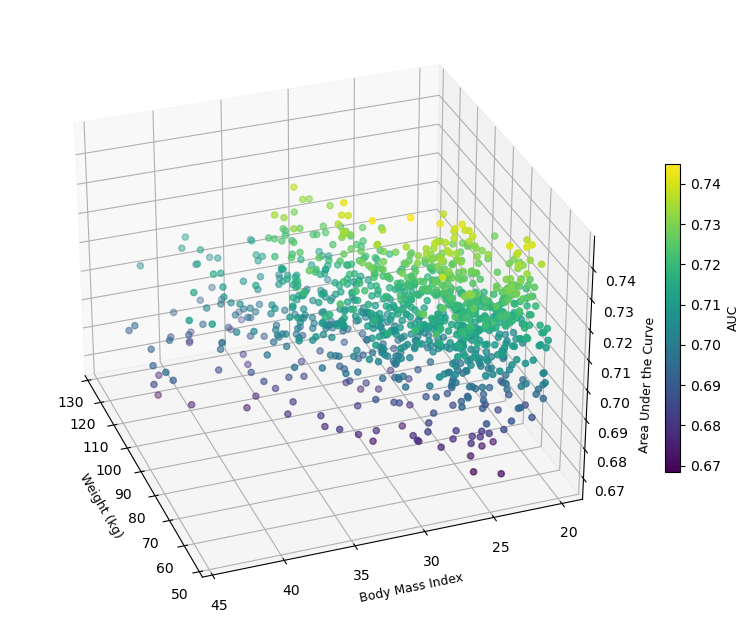

Plot saved as nhanes_1_roc.png


In [6]:
# Create figure for 3D plot of AUC vs Weight and BMI
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot with colormap
# x2[:1000, 2] = Weight (index 2 in feature array)
# x2[:1000, 3] = BMI (index 3 in feature array)
# areas = AUC values for first 1000 participants
scatter = ax.scatter(
    x2[:1000, 2],     # X-axis: Weight (kg)
    x2[:1000, 3],     # Y-axis: Body Mass Index
    areas,            # Z-axis: Area Under the Curve
    c=areas,          # Color by AUC value
    cmap='viridis',   # Colormap
    s=20              # Point size
)

# Configure labels and visualization
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Body Mass Index')
ax.set_zlabel('Area Under the Curve')
ax.grid(True)
ax.set_facecolor('white')  # White background
ax.view_init(elev=30, azim=160)  # Viewing angle

# Add colorbar
plt.colorbar(scatter, ax=ax, label='AUC', shrink=0.5)

# Save figure
plt.savefig('nhanes_1_roc.png', bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()

print('Plot saved as nhanes_1_roc.png')